# 🗺️ **Surface Contouring and Frontal Analysis**
---

### **Context**
Here, we extend the country-level surface weather data analysis workflow established in the previous notebook (01_surface_weather_reports.ipynb) to a **continental-scale** domain and introduce the **objective analysis** techniques required for **synoptic-scale interpretation**. Specifically, we grid and contour mean sea-level pressure and air temperature to resolve pressure centers and the prevailing air mass distribution, incorporate dewpoint and wind observations to identify surface frontal zones, and map 500 hPa radiosonde observations for a complementary upper-air overview.

### **Learning Goals:**
- 🎯 **Goal 1 | Continental Coverage**: Extend the surface weather data analysis workflow from the country-level to the continental-scale METAR network
- 🎯 **Goal 2 | Isobaric Analysis**: Grid and contour mean sea-level pressure to identify high (H) and low (L) pressure centers 
- 🎯 **Goal 3 | Frontal Analysis**: Identify surface frontal zones from temperature, pressure, moisture, and wind observations, and validate against an operational analysis chart
- 🎯 **Goal 4 | Upper-Air Overview**: Map the 500 hPa wind, temperature, geopotential height, and dew-point depression from European radiosonde observations

**Run the tutorial via free cloud platforms:**

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/one-weather-lab/weather-analysis-and-forecasting/HEAD)


---

## ⚙️ Setup

First, let's import the necessary libraries and configure our environment.

In [1]:
# Import required libraries
from __future__ import annotations

import sys
import time as _time
import warnings
from pathlib import Path

# Core data science stack
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)

# Visualization
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Add local utils to path
sys.path.insert(0, str(Path('../utils').resolve()))

# Import our custom utilities
from iem_raw import fetch_iem_raw
from noaa_realtime import fetch_noaa_realtime
from raob_helpers import fetch_igra2_europe, fetch_europe_raob_fields
from metar_helpers import (
    decode_metar_row,
    check_dewpoint_consistency,
    check_rh_range,
    check_wind_temporal_spike,
)
from plot_helpers import (
    fetch_ourairports_europe,
    build_europe_network_plot_df,
    plot_europe_metar_network,
    plot_europe_mslp_raw,
    plot_europe_isobars,
    plot_europe_isobars_hl,
    plot_europe_enhanced_station_isobars,
    plot_europe_isobars_wind,
    plot_europe_isobars_temperature,
    plot_europe_isobars_temperature_humidity,
    plot_europe_500hpa_stations,
)
from contouring_helpers import (
    build_europe_grid,
    grid_variable,
    smooth_grid,
    grid_surface_fields,
)
from wyoming_raob import (
    fetch_latest_sounding,
    fetch_retrospective_sounding,
)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set up nice plotting defaults
plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('[OK]   All libraries loaded successfully!')

[OK]   All libraries loaded successfully!


---

# Section 1: Continental Coverage

## 1.1 Extending to the Continental-Scale METAR Network

The surface weather data analysis workflow in 01_surface_weather_reports.ipynb was built around a country-level station network, focusing specifically on Greece with approximately 34 HNMS aviation weather stations. Extending the workflow to a continental-scale network is a necessary next step, given that pressure systems and frontal zones operate at **synoptic spatial scales** that exceed any single country's station coverage

To achieve this, station metadata for the target domain is sourced from the [OurAirports open database](https://ourairports.com/data/). The catalogue is filtered to the bounding box defined in the Configuration cell below, and the resulting station list is passed to the same NOAA NWS and IEM data pipelines used in the previous notebook.

## 1.2 Select Data Mode and Analysis Domain

**Instructions:**
1. **Choose your Data Mode** in the cell below (`'realtime'` for the latest observations or `'retrospective'` for historical data)
2. **Set your target date** (only applicable for `'retrospective'` mode)
3. **Adjust the bounding box coordinates** to change the analysis domain
4. **Adjust gridding and contouring parameters** to modify interpolation resolution and contour intervals

In [2]:
# =============================================================================
# CONFIGURATION SECTION
# =============================================================================

# ---------------------------------------------------------------------------
# DATA MODE
# ---------------------------------------------------------------------------
# 'realtime'     -> fetch the LATEST available observation for each station
#                   directly from the NOAA NWS FTP server.
#
# 'retrospective' -> fetch a full day of historical records from the IEM
#                   METAR archive.
DATA_MODE = 'realtime'   # <-- CHANGE TO 'retrospective' FOR HISTORICAL DATA

# ---------------------------------------------------------------------------
# RETROSPECTIVE SETTINGS (used only when DATA_MODE = 'retrospective')
# ---------------------------------------------------------------------------
TARGET_DATE = '2025-11-29'   # <-- MODIFY THIS (YYYY-MM-DD)

# ---------------------------------------------------------------------------
# TARGET DOMAIN (default: European domain)
# ---------------------------------------------------------------------------
LON_MIN, LON_MAX = -25, 45
LAT_MIN, LAT_MAX =  30, 72

# ---------------------------------------------------------------------------
# GRIDDING 
# ---------------------------------------------------------------------------
GRID_RESOLUTION = 0.25   # degrees (~28 km)
SIGMA_MSLP       = 3      # Gaussian smoothing sigma -- sea-level pressure
SIGMA_T         = 3      # Gaussian smoothing sigma -- temperature
SIGMA_TD        = 3      # Gaussian smoothing sigma -- dewpoint

# ---------------------------------------------------------------------------
# CONTOUR INTERVALS
# ---------------------------------------------------------------------------
ISOBAR_INTERVAL   = 4           # hPa (WMO standard interval)
ISOTHERM_INTERVAL = 2           # deg C

# =============================================================================
print(f"[DATA MODE] {DATA_MODE.upper()}",
      f'| Date: {TARGET_DATE}' if DATA_MODE == 'retrospective' else '')
print(f"[DOMAIN   ] lon {LON_MIN} to {LON_MAX} deg  lat {LAT_MIN} to {LAT_MAX} deg")
print(f"[GRID     ] {GRID_RESOLUTION} deg resolution  |  sigma_MSLP={SIGMA_MSLP}  sigma_T={SIGMA_T}")

[DATA MODE] REALTIME 
[DOMAIN   ] lon -25 to 45 deg  lat 30 to 72 deg
[GRID     ] 0.25 deg resolution  |  sigma_MSLP=3  sigma_T=3


## 1.3 Data Acquisition and Processing

The three cells below execute the full data acquisition and processing chain.  

First, the station coordinate table is retrieved based on the OurAirports global catalogue and the target domain.

> **Note station coverage:** Only **large** and **medium** airports are included to reduce download times. 

Then, METAR data are fetched from the correct data source based on `DATA_MODE`.

> **Note for real-time mode:** observations older than **50 minutes** are automatically discarded.

Finally, all raw METAR strings are decoded and converted into SI-consistent variables, including relative humidity, which is computed from air temperature and dewpoint, and a three-tier Quality Control (QC) pipeline is applied: (i) validity check on relative humidity, (ii) temporal wind spike detection, and (iii) internal consistency between dewpoint and air temperature. Observations that fail any check are flagged and excluded from the clean dataset used in all subsequent analysis steps


In [3]:
# Fetch European airport metadata from OurAirports
station_meta = fetch_ourairports_europe(LAT_MIN, LAT_MAX, LON_MIN, LON_MAX)

print(f"[OK]    {len(station_meta)} European stations loaded")
display(station_meta.head(8))

[OK]    1103 European stations loaded


,icao_code,name,latitude_deg,longitude_deg,elevation_m
0,BGCO,Neerlerit Inaat Airport,70.743103,-22.650499,13.7
1,BIAR,Akureyri International Airport,65.656573,-18.072018,1.8
2,BIBD,Bildudalur Airport,65.641296,-23.546200,5.5
3,BIEG,Egilsstaðir Airport,65.283302,-14.401400,23.2
4,BIGR,Grímsey Airport,66.545800,-18.017300,20.1
5,BIHN,Hornafjörður Airport,64.295601,-15.227200,7.3
6,BIHU,Húsavík Airport,65.952301,-17.426001,14.6
7,BIIS,Ísafjörður Airport,66.058098,-23.135300,2.4


In [4]:
icao_list = station_meta['icao_code'].tolist()
_start = _time.time()

# ---------------------------------------------------------------------------
# Dispatch: real-time vs retrospective
# ---------------------------------------------------------------------------
if DATA_MODE == 'realtime':
    print(f"[INFO] Fetching latest METAR for {len(icao_list)} European stations ...")
    df_raw = fetch_noaa_realtime(icao_list)
    n_ok      = len(df_raw)
    n_skipped = len(icao_list) - n_ok
    print(f"[OK]   {n_ok} current observation(s) retrieved.")
    if n_skipped:
        print(f"[SKIP] {n_skipped} station(s) had no data within the staleness window.")

elif DATA_MODE == 'retrospective':
    print(f"[INFO] Fetching historical METAR from IEM for {TARGET_DATE} ...")
    df_raw = fetch_iem_raw(
        stations=icao_list,
        start_date=TARGET_DATE,
        end_date=TARGET_DATE,
    )
    print(f"[OK]   {len(df_raw)} observation(s) downloaded.")

else:
    raise ValueError(f"Unknown DATA_MODE: '{DATA_MODE}'. Use 'realtime' or 'retrospective'.")

print(f"[TIME ] {(_time.time() - _start):.1f} s")

2026-04-15 21:23:07 | INFO | [NOAA] Fetching METAR for 1103 station(s)  |  workers=32  |  cut-off=50 min  |  retries=3  |  ref UTC 2026-04-15 18:23:07


[INFO] Fetching latest METAR for 1103 European stations ...


2026-04-15 21:25:38 | INFO | [NOAA] Round 0: 643 ok  |  189 retryable  |  271 permanent-skip
2026-04-15 21:25:38 | INFO | [NOAA] Retry 1/3: 189 station(s) pending  |  back-off 3 s  |  workers=8
2026-04-15 21:27:25 | INFO | [NOAA] Retry 1/3 result: +112 ok  |  38 still retryable
2026-04-15 21:27:25 | INFO | [NOAA] Retry 2/3: 38 station(s) pending  |  back-off 6 s  |  workers=8
2026-04-15 21:27:47 | INFO | [NOAA] Retry 2/3 result: +29 ok  |  3 still retryable
2026-04-15 21:27:47 | INFO | [NOAA] Retry 3/3: 3 station(s) pending  |  back-off 12 s  |  workers=8
2026-04-15 21:28:01 | INFO | [NOAA] Retry 3/3 result: +2 ok  |  0 still retryable
2026-04-15 21:28:01 | INFO | [NOAA] Retrieved 786 observation(s).
2026-04-15 21:28:01 | INFO | [NOAA] Permanent skips: 317  —  future: 1  |  http_404: 157  |  stale: 159


[OK]   786 current observation(s) retrieved.
[SKIP] 317 station(s) had no data within the staleness window.
[TIME ] 293.8 s


In [5]:
# Decode and convert all data into SI-consistent units.
df_decoded = df_raw.apply(decode_metar_row, axis=1)

# ---------------------------------------------------------------------------
# QC Check 1 (Validity): Relative Humidity within [0, 100 %]
# ---------------------------------------------------------------------------
df_decoded['qc_rh'] = df_decoded['relh'].apply(check_rh_range)

# ---------------------------------------------------------------------------
# QC Check 2 (Temporal): Wind speed change between consecutive observations
# Threshold: 10.30 m/s per hour (equivalent to 20 kt/h).
# Requires >= 2 obs per station; skipped automatically if only one obs.
# ---------------------------------------------------------------------------
df_decoded = df_decoded.sort_values(['station', 'valid']).reset_index(drop=True)
df_decoded['qc_wind_temporal'] = True   # default: all pass

for stn, grp in df_decoded.groupby('station'):
    if len(grp) < 2:
        continue
    idxs = grp.index.tolist()
    for j in range(1, len(idxs)):
        i_now  = idxs[j]
        i_prev = idxs[j - 1]
        dt_h = (df_decoded.at[i_now, 'valid'] - df_decoded.at[i_prev, 'valid']).total_seconds() / 3600.0
        df_decoded.at[i_now, 'qc_wind_temporal'] = check_wind_temporal_spike(
            df_decoded.at[i_now, 'wspd_ms'], df_decoded.at[i_prev, 'wspd_ms'], dt_h
        )

# ---------------------------------------------------------------------------
# QC Check 3 (Internal Consistency): Dewpoint < Air Temperature
# ---------------------------------------------------------------------------
df_decoded['dewpoint_depression'] = df_decoded['temp_c'] - df_decoded['dwpt_c']
df_decoded['qc_td_t'] = df_decoded.apply(
    lambda r: check_dewpoint_consistency(r['temp_c'], r['dwpt_c']), axis=1
)

# ---------------------------------------------------------------------------
# Combined flag: fail ANY check -> flagged
# ---------------------------------------------------------------------------
df_decoded['qc_flag'] = ~(df_decoded['qc_rh'] & df_decoded['qc_wind_temporal'] & df_decoded['qc_td_t'])

# ---------------------------------------------------------------------------
# Summary report
# ---------------------------------------------------------------------------
n_total   = len(df_decoded)
n_flagged = int(df_decoded['qc_flag'].sum())

print('QC Pipeline Results')
print('=' * 55)
print(f'  Total observations           : {n_total}')
print(f'  QC 1 failures  (RH bounds)   : {int((~df_decoded["qc_rh"]).sum())}')
print(f'  QC 2 failures  (wind spike)  : {int((~df_decoded["qc_wind_temporal"]).sum())}')
print(f'  QC 3 failures  (Td >= T)     : {int((~df_decoded["qc_td_t"]).sum())}')
print(f'  Total flagged                : {n_flagged} ({100*n_flagged/max(n_total,1):.1f}%)')
print(f'  Passed all checks            : {n_total - n_flagged}')

if n_flagged > 0:
    print('\nFlagged rows:')
    disp_cols = ['station', 'valid', 'temp_c', 'dwpt_c', 'relh', 'wspd_ms',
                 'qc_rh', 'qc_wind_temporal', 'qc_td_t']
    display(df_decoded[df_decoded['qc_flag']][[c for c in disp_cols if c in df_decoded.columns]])
else:
    print('\n[OK] All observations passed the QC pipeline.')

# Keep only clean observations
df_clean = df_decoded[~df_decoded['qc_flag']].copy()
print(f'\n[OK] Clean dataset: {len(df_clean)} observations from {df_clean["station"].nunique()} stations')


QC Pipeline Results
  Total observations           : 786
  QC 1 failures  (RH bounds)   : 0
  QC 2 failures  (wind spike)  : 0
  QC 3 failures  (Td >= T)     : 0
  Total flagged                : 0 (0.0%)
  Passed all checks            : 786

[OK] All observations passed the QC pipeline.

[OK] Clean dataset: 786 observations from 786 stations


## 1.4 Continental-Scale Network Visualization

The continental-scale station plot map displays wind, temperature, relative humidity, and mean sea-level pressure at each reporting location across the European domain, providing a **synoptic-scale** overview of the prevailing **atmospheric conditions**.

> **Note on observational coverage**: Even at continental scale, the METAR network captures only airport-based stations. Coverage gaps are therefore expected not only over data-sparse land areas but across the full marine domain, restricting the completeness of the synoptic analysis. 

[OK]   786 stations matched to coordinates


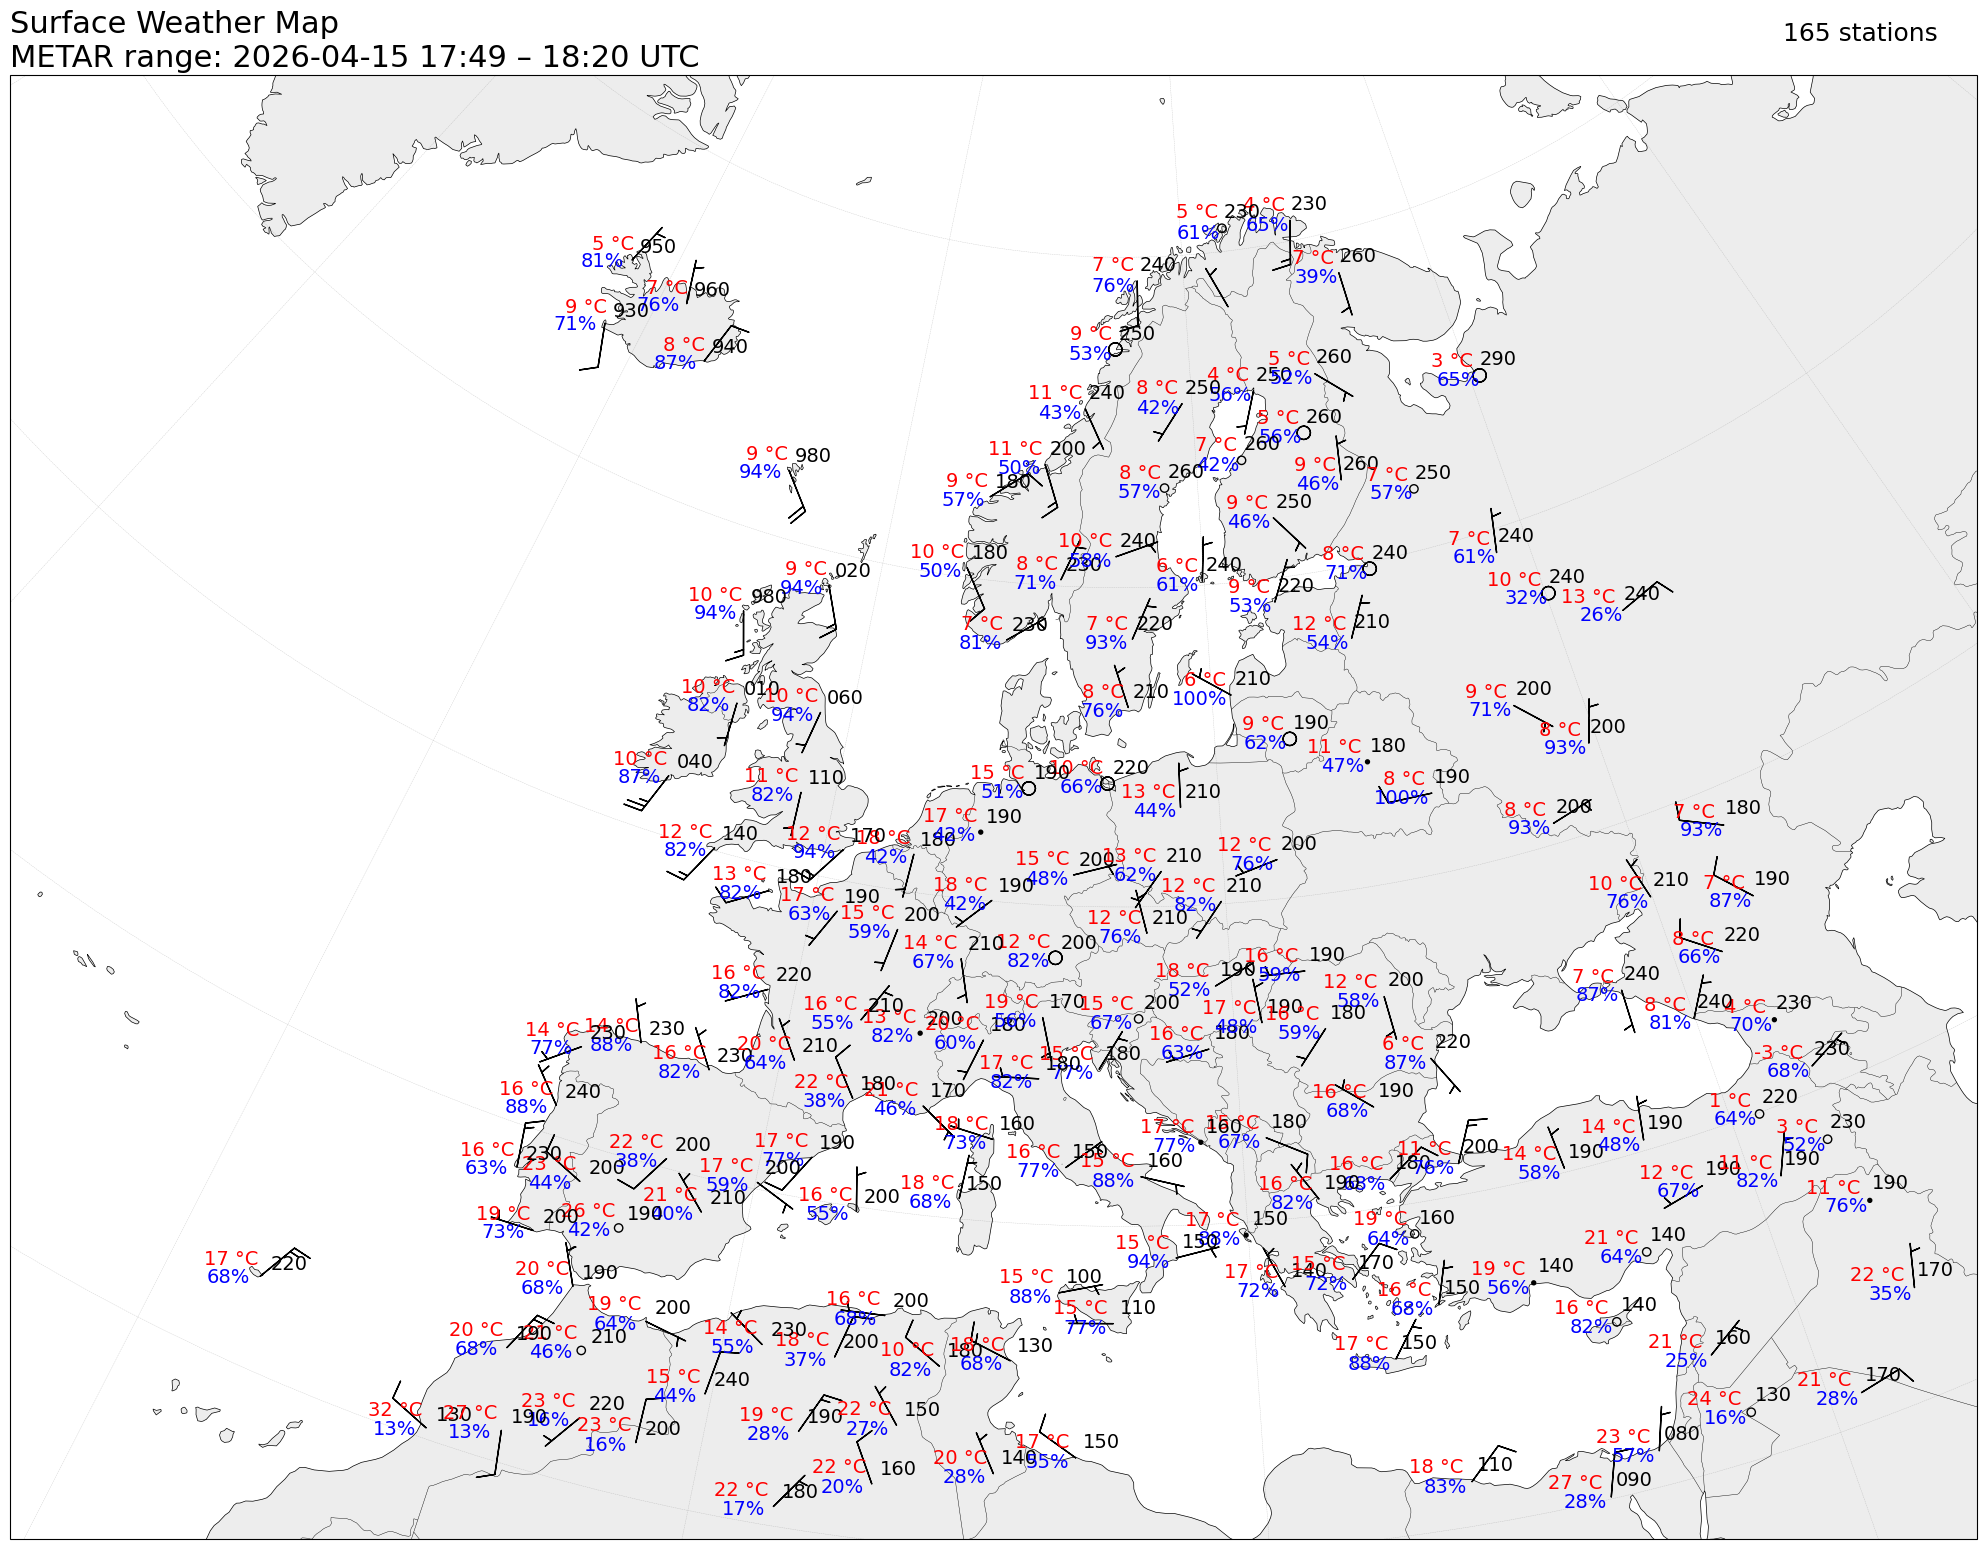

[OK]   Figure saved to E:\Professorship (2026 -\01_Projects\07_Active_Teaching\2025-2026\Μ225 Weather Analysis and Forecasting\weather-analysis-and-forecasting\outputs\europe_metar_network_20260415_1828.png


In [6]:
# Build the plot-ready DataFrame
df_plot = build_europe_network_plot_df(df_decoded, station_meta)
print(f"[OK]   {len(df_plot)} stations matched to coordinates")

# To avoid overcrowding the map, a spatial thinning of 200 km is applied in the plotting function.
if len(df_plot) > 0:
    out_path = plot_europe_metar_network(df_plot, output_dir='../outputs')
    plt.show()
    print(f'[OK]   Figure saved to {out_path}')

---

# Section 2: Isobaric Analysis

## 2.1 Understanding Mean Sea-Level Pressure Analysis

### Mean Sea-Level Pressure

Raw station pressure reflects both the atmospheric state and the elevation of the observing station. **Mean sea-level pressure** (MSLP) removes the elevation component by reducing each observation to a common reference level, isolating the true horizontal pressure differences that drive large-scale atmospheric motion.

### Pressure Centers and Atmospheric Circulation

The spatial pattern of MSLP at a given time reveals two classes of pressure center: **Highs** (anticyclones) and **Lows** (cyclones). These indicate regions of surface **divergence** and **convergence**, respectively, with direct consequences for vertical motion and weather, as summarized in the table below. 

| Pressure Center    | Surface Flow | Vertical Motion | Associated Weather          |
|--------------------|--------------|-----------------|-----------------------------|
| Low (Cyclone)      | Convergent   | Rising air      | Clouds, precipitation       |
| High (Anticyclone) | Divergent    | Sinking air     | Clear skies, dry conditions |

### Isobars

Isobars are drawn at standard hPa intervals using 1000 hPa as the reference baseline. **Closed patterns** identify Highs and Lows. In addition, **closely spaced isobars** indicate a strong pressure gradient and correspondingly strong winds, whereas **widely spaced isobars** indicate a weak pressure gradient and correspondingly weak winds. 

## 2.2 Constructing the Isobaric Map

### 2.2.1 Gridding and Smoothing

Manual contouring traces lines of equal MSLP value by scanning the station observations, selecting a contour interval, and interpolating between adjacent reporting points (subjective analysis). The cell below performs the equivalent procedure automatically (**objective analysis**). Specifically, it grids station observations onto a regular grid and applies Gaussian smoothing to suppress interpolation noise and produce a field suitable for contouring

In [8]:
# Merge decoded data with coordinates for gridding
df_geo = df_plot.copy()  # df_plot already has lat/lon from station_meta

# Build the regular grid
grid_lon, grid_lat = build_europe_grid(LON_MIN, LON_MAX, LAT_MIN, LAT_MAX, GRID_RESOLUTION)

# Grid and smooth all surface fields
grids = grid_surface_fields(df_geo, grid_lon, grid_lat, SIGMA_MSLP, SIGMA_T, SIGMA_TD)

print(f"[OK]   Gridding and smoothing complete")

2026-04-15 21:28:58 | INFO | [GRID] MSLP: 780 valid observations
2026-04-15 21:28:58 | INFO | [GRID] Temperature: 779 valid observations
2026-04-15 21:28:59 | INFO | [GRID] Dewpoint: 779 valid observations


[OK]   Gridding and smoothing complete


### 2.2.2 Isobars

The cell below contours the smoothed MSLP field at the defined `ISOBAR_INTERVAL`. Every other contour line is labelled with its MSLP value.

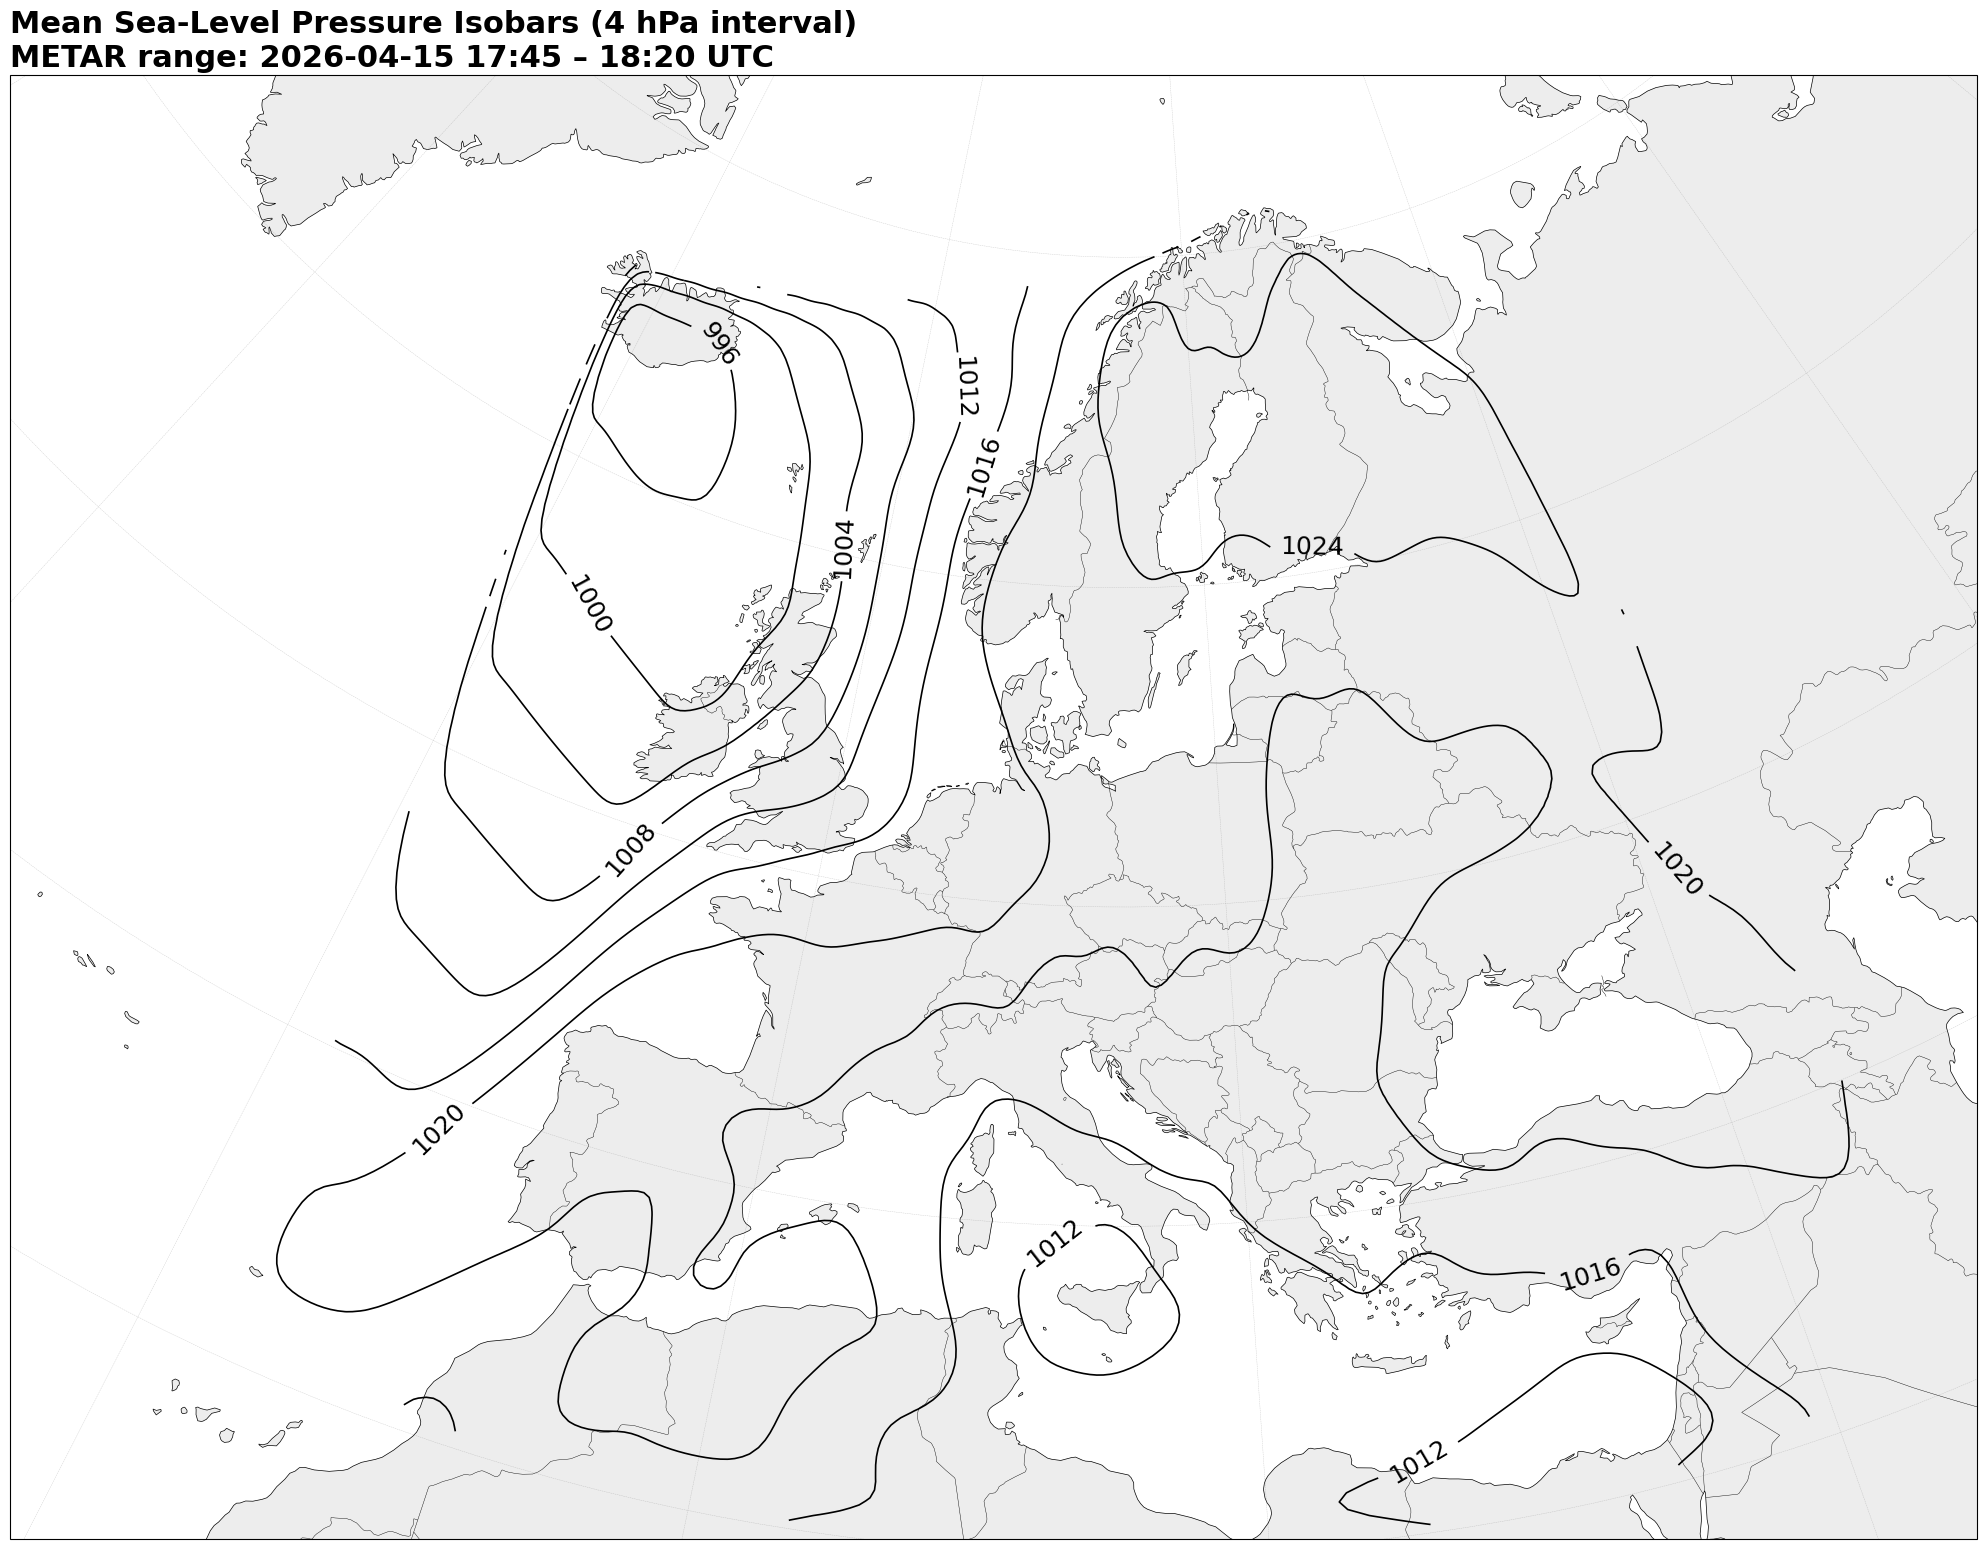

[OK]    Figure saved to E:\Professorship (2026 -\01_Projects\07_Active_Teaching\2025-2026\Μ225 Weather Analysis and Forecasting\weather-analysis-and-forecasting\outputs\europe_isobars_only_20260415_1833.png


In [12]:
# Isobar-only map
out_path = plot_europe_isobars(
    grid_lon, grid_lat, grids['mslp'],
    output_dir='../outputs',
    isobar_interval=ISOBAR_INTERVAL,
    df_geo = df_geo
)
print(f"[OK]    Figure saved to {out_path}")

---

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 4px solid #ffc107;">

## 📝 Task 2.1: Identify Pressure Centers

**Goal:** Identify pressure centers manually from the isobar field before automated detection.

Examine the isobar field and complete the following analysis:

1. Locate all closed isobar patterns on the map
2. Note the approximate geographic location of each center
3. Estimate the central pressure from the surrounding isobars
4. Classify each center as a **High** or **Low** 

</div>

### 2.2.3 Pressure Centers

The cell below detects local maxima and minima of the smoothed MSLP field and labels each center H (High) or L (Low) with its central pressure value.

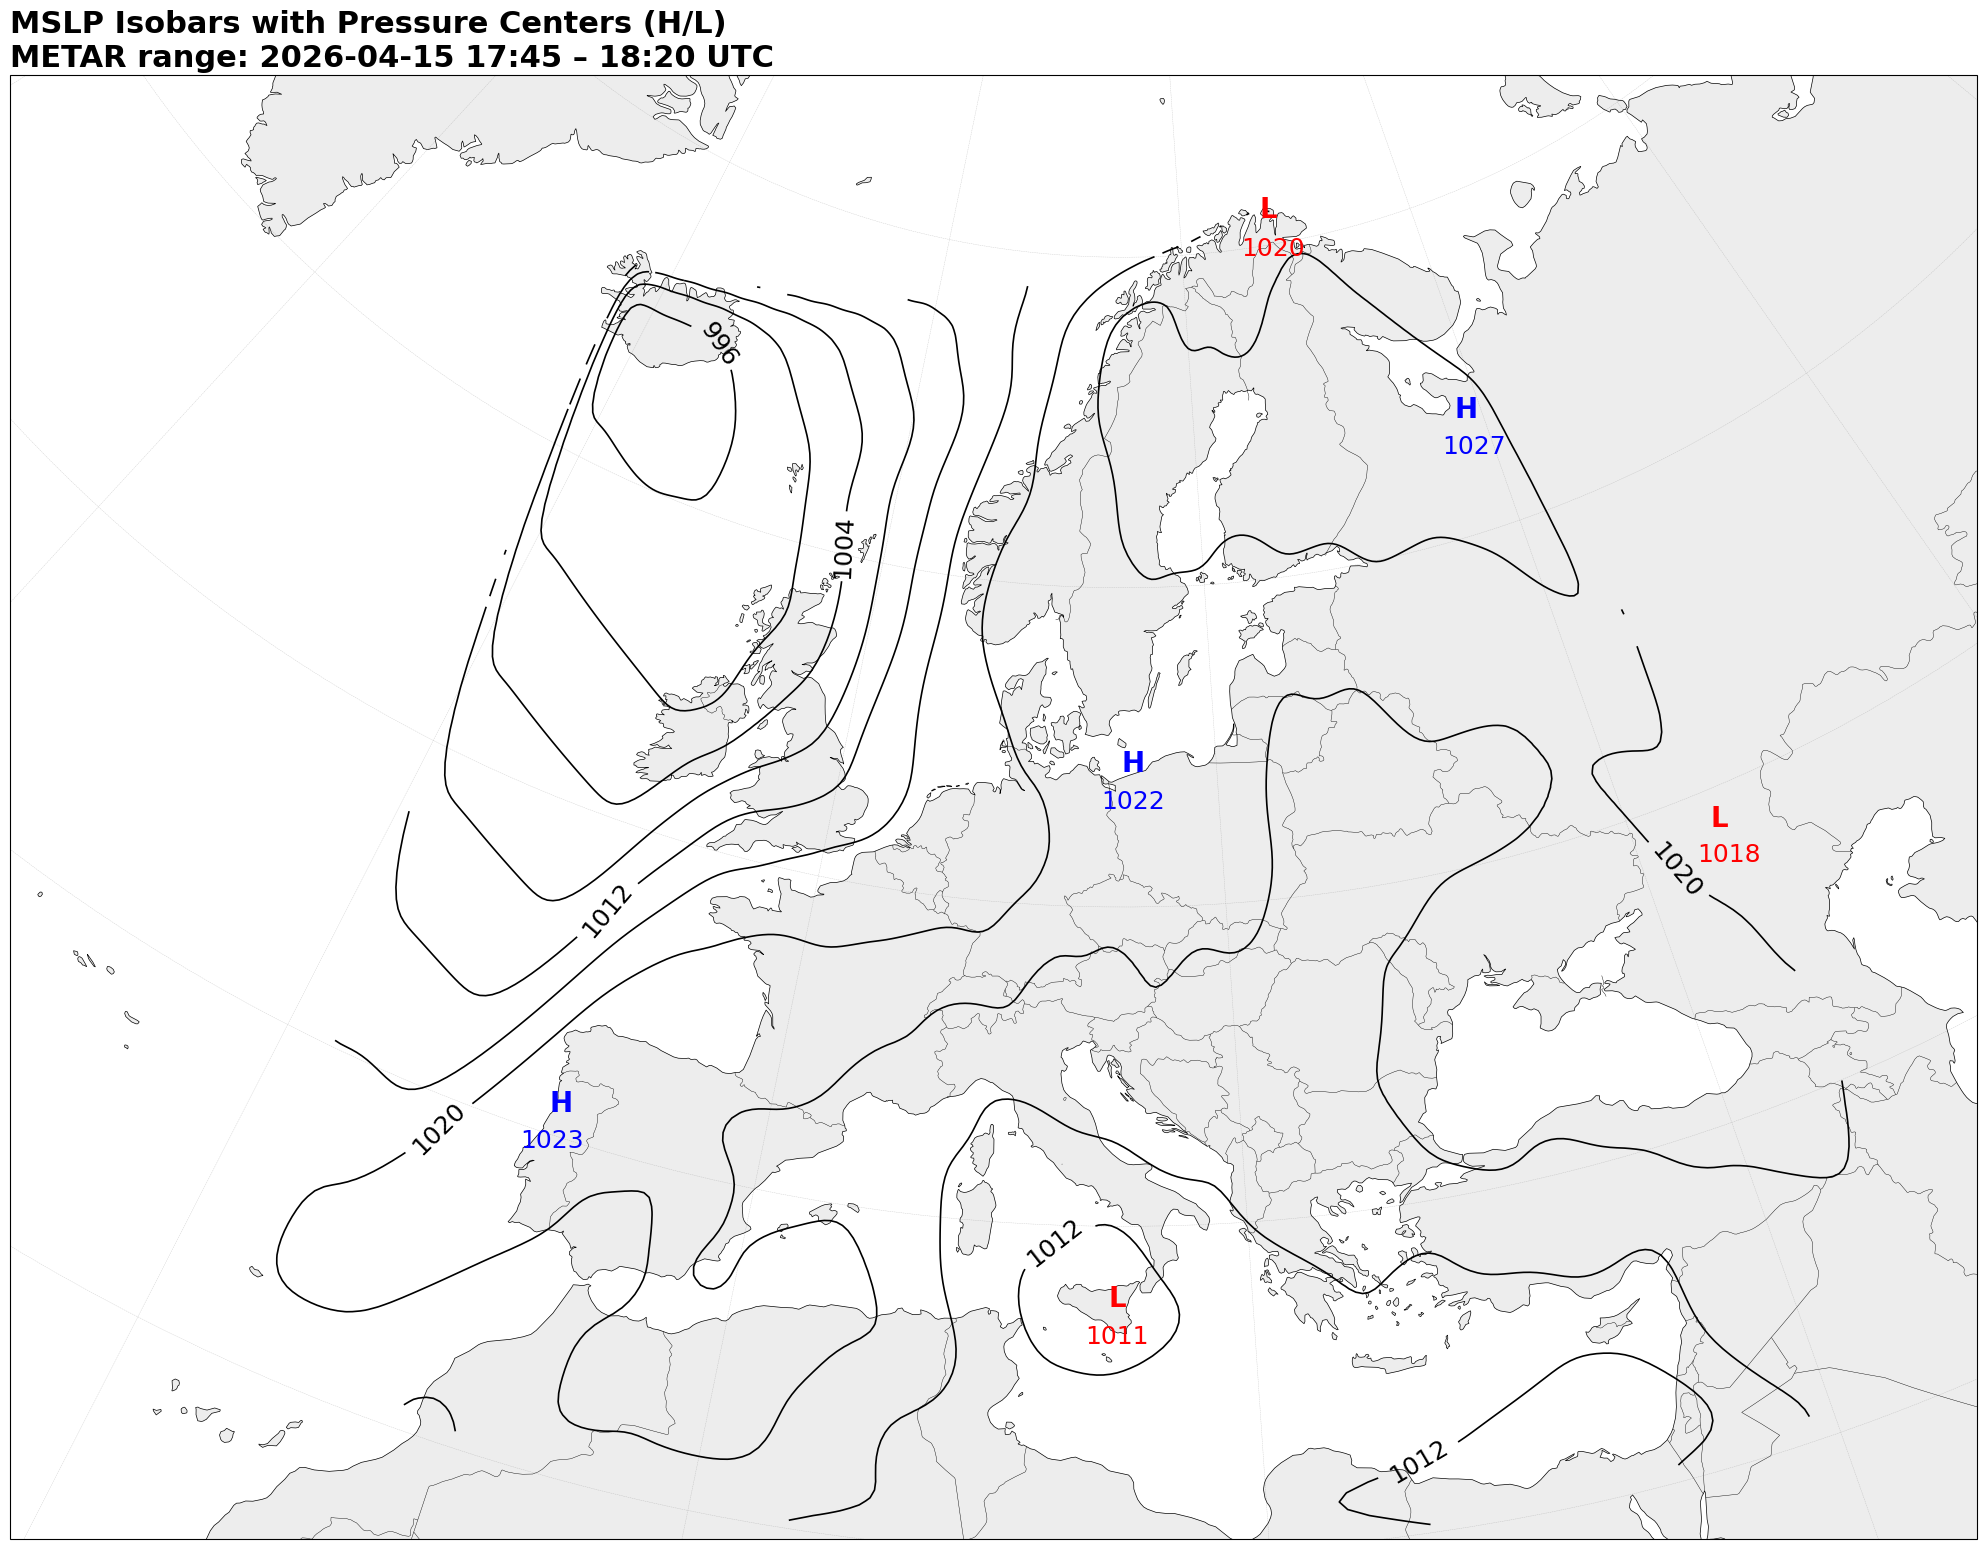

[OK]    Figure saved to E:\Professorship (2026 -\01_Projects\07_Active_Teaching\2025-2026\Μ225 Weather Analysis and Forecasting\weather-analysis-and-forecasting\outputs\europe_isobars_hl_20260415_1834.png


In [13]:
# Isobars with H/L center
out_path = plot_europe_isobars_hl(
    grid_lon, grid_lat, grids['mslp'],
    output_dir='../outputs',
    isobar_interval=ISOBAR_INTERVAL,
    df_geo = df_geo
)
print(f"[OK]    Figure saved to {out_path}")

---

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 4px solid #ffc107;">

## 📝 Task 2.2: Atmospheric Circulation and Pressure Gradient

**Goal:** Infer the wind field from the isobar geometry before comparing against observed wind barbs.

Examine the isobar and pressure center map and complete the following analysis:

1. Indicate the expected **wind flow** direction around each High and Low
2. Identify zones of strong **wind speed**

</div>

### 2.2.4 Wind Barbs

The cell below overlays wind barbs on the isobar and pressure center map to show how observed wind speed and direction correspond to the orientation and spacing of the isobars. 

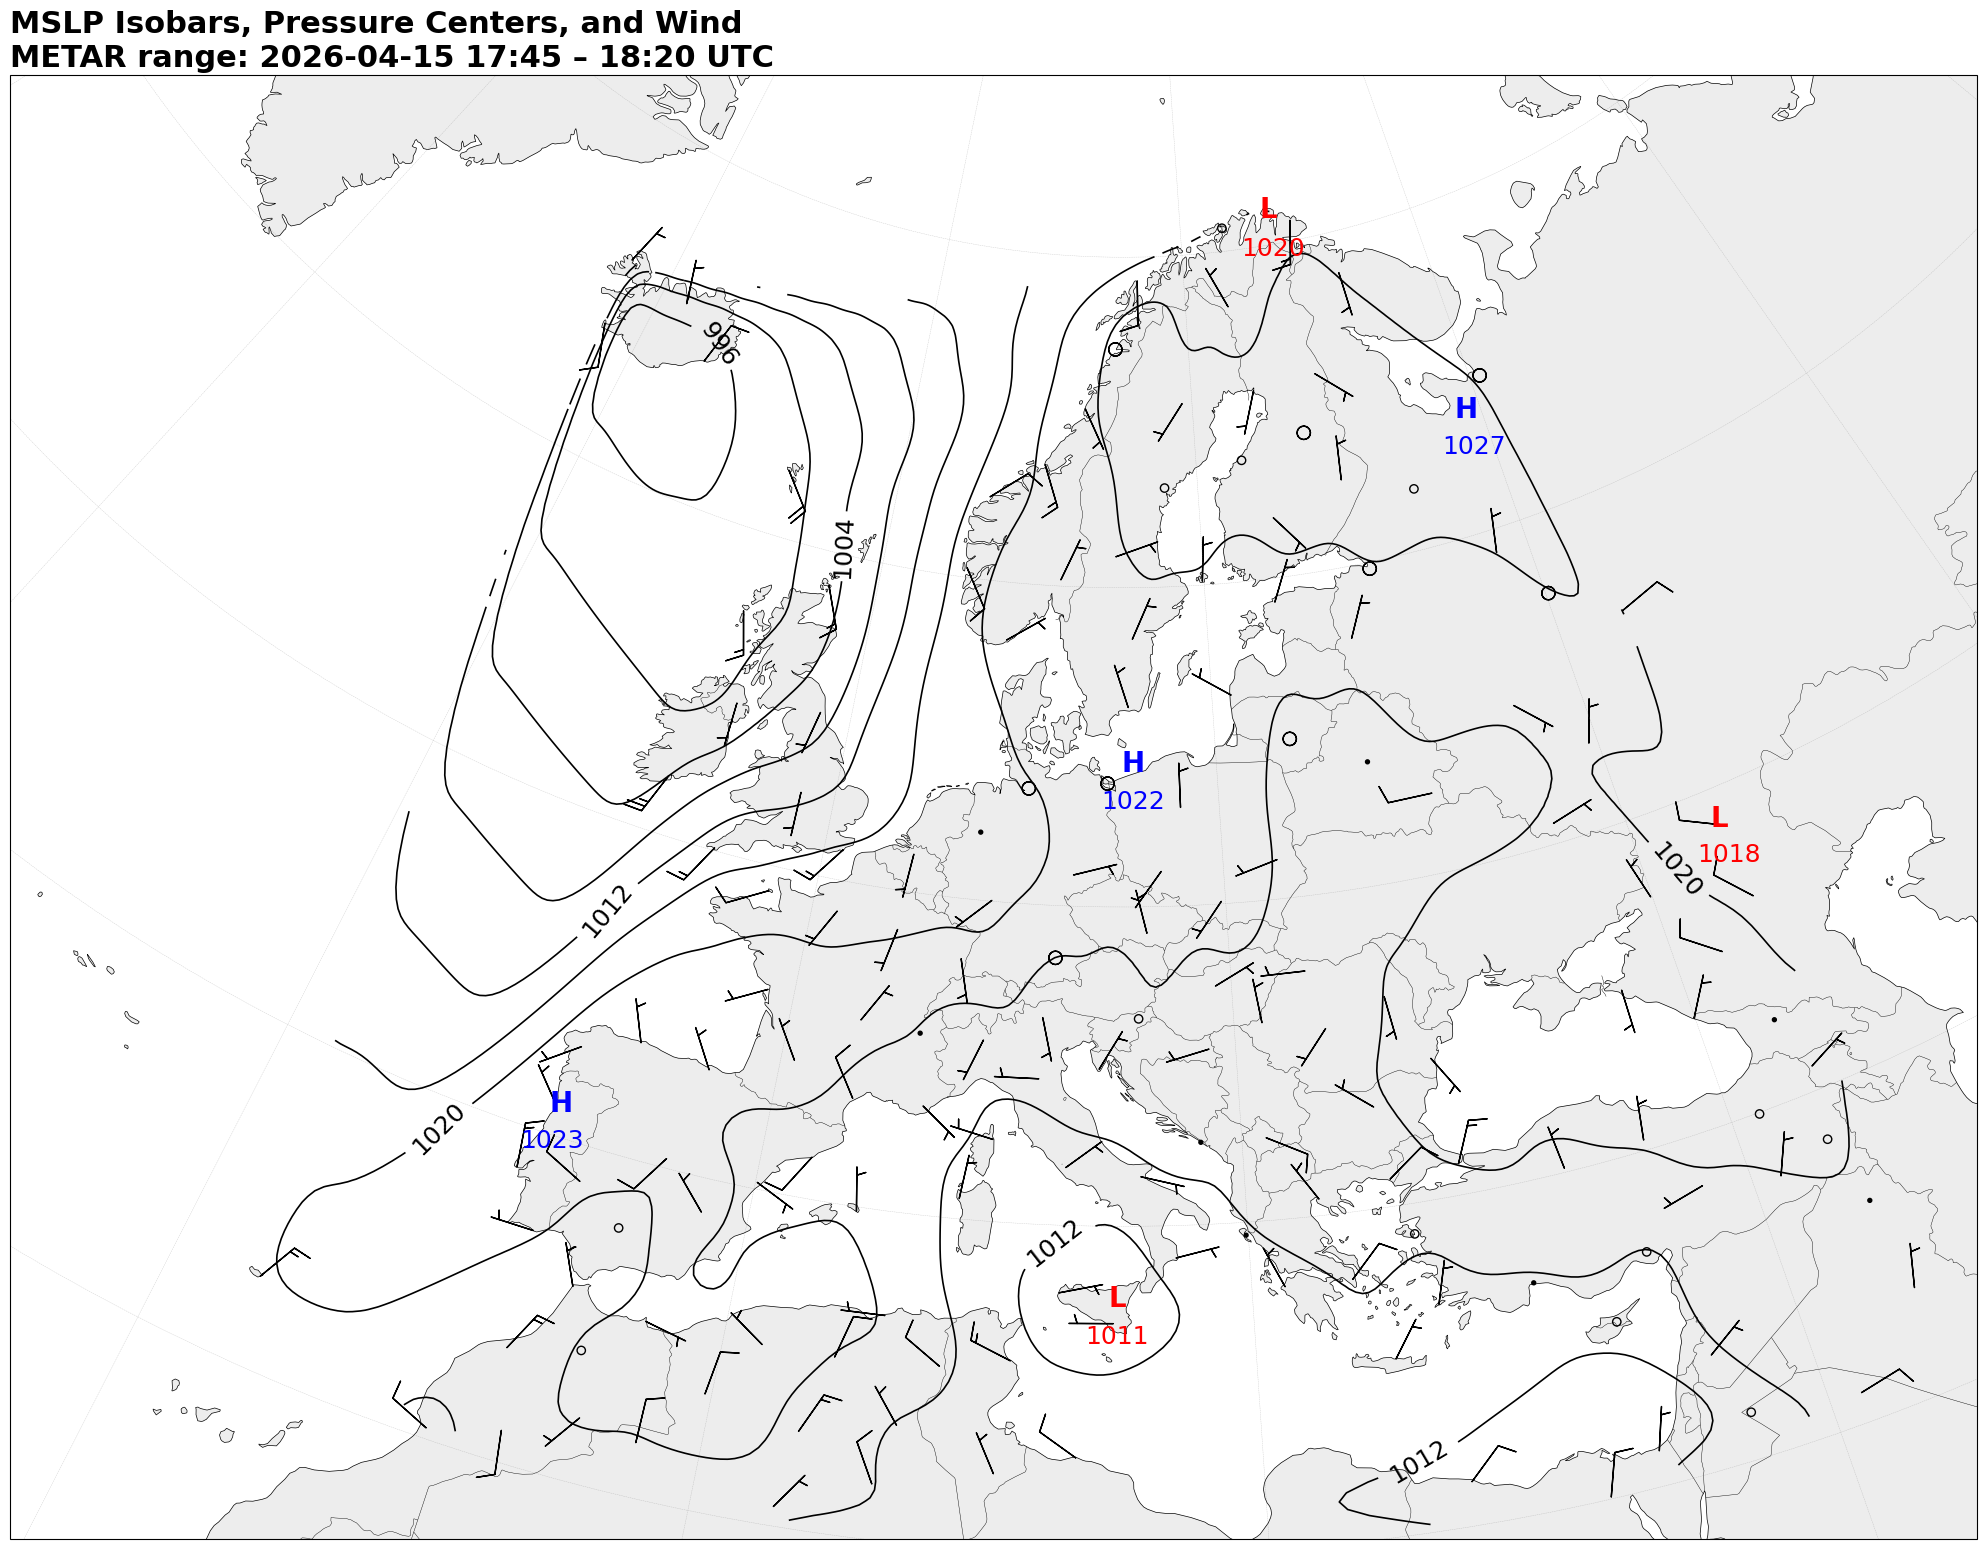

[OK]   Figure saved to E:\Professorship (2026 -\01_Projects\07_Active_Teaching\2025-2026\Μ225 Weather Analysis and Forecasting\weather-analysis-and-forecasting\outputs\europe_isobars_wind_20260415_1834.png


In [15]:
# Isobars + H/L pressure centers + wind barbs
out_path = plot_europe_isobars_wind(
    df_plot, grid_lon, grid_lat, grids['mslp'],
    output_dir='../outputs',
    isobar_interval=ISOBAR_INTERVAL,
)
print(f'[OK]   Figure saved to {out_path}')

---

# Section 3: Frontal Analysis

## 3.1 Understanding Frontal Zones

Frontal zones are boundaries between air masses of contrasting temperature, moisture, and wind characteristics. Isotherms delineate warm and cold regions and provide the first indication of where these boundaries may lie, but near surface temperature alone is insufficient for frontal identification. Therefore, the following **four criteria** are examined simultaneously: 

- Air temperature change across the front
- Air moisture change across the front
- Wind shift across the front
- MSLP minimum along the front, with falling pressure on approach and rising pressure after passage 

> **Note on frontal analysis**: Even when all four criteria are satisfied, the identified zones represent the near-surface projection of **three-dimensional structures** that extend vertically through the troposphere. Surface features must therefore be cross-referenced with **upper-air charts** (e.g. 850 hPa temperature) for complete frontal analysis.

## 3.2 Identifying Frontal Zones from Surface Observations

### 3.2.1 Temperature Isotherms

The cell below creates a two-panel map below that presents the isobaric and wind analysis alongside gridded **isotherms** (red contours),  enabling direct comparison of the thermal, pressure and wind fields. Zones of strong temperature gradient, where isotherms are closely spaced, provide the first surface indication of a **frontal boundary**.

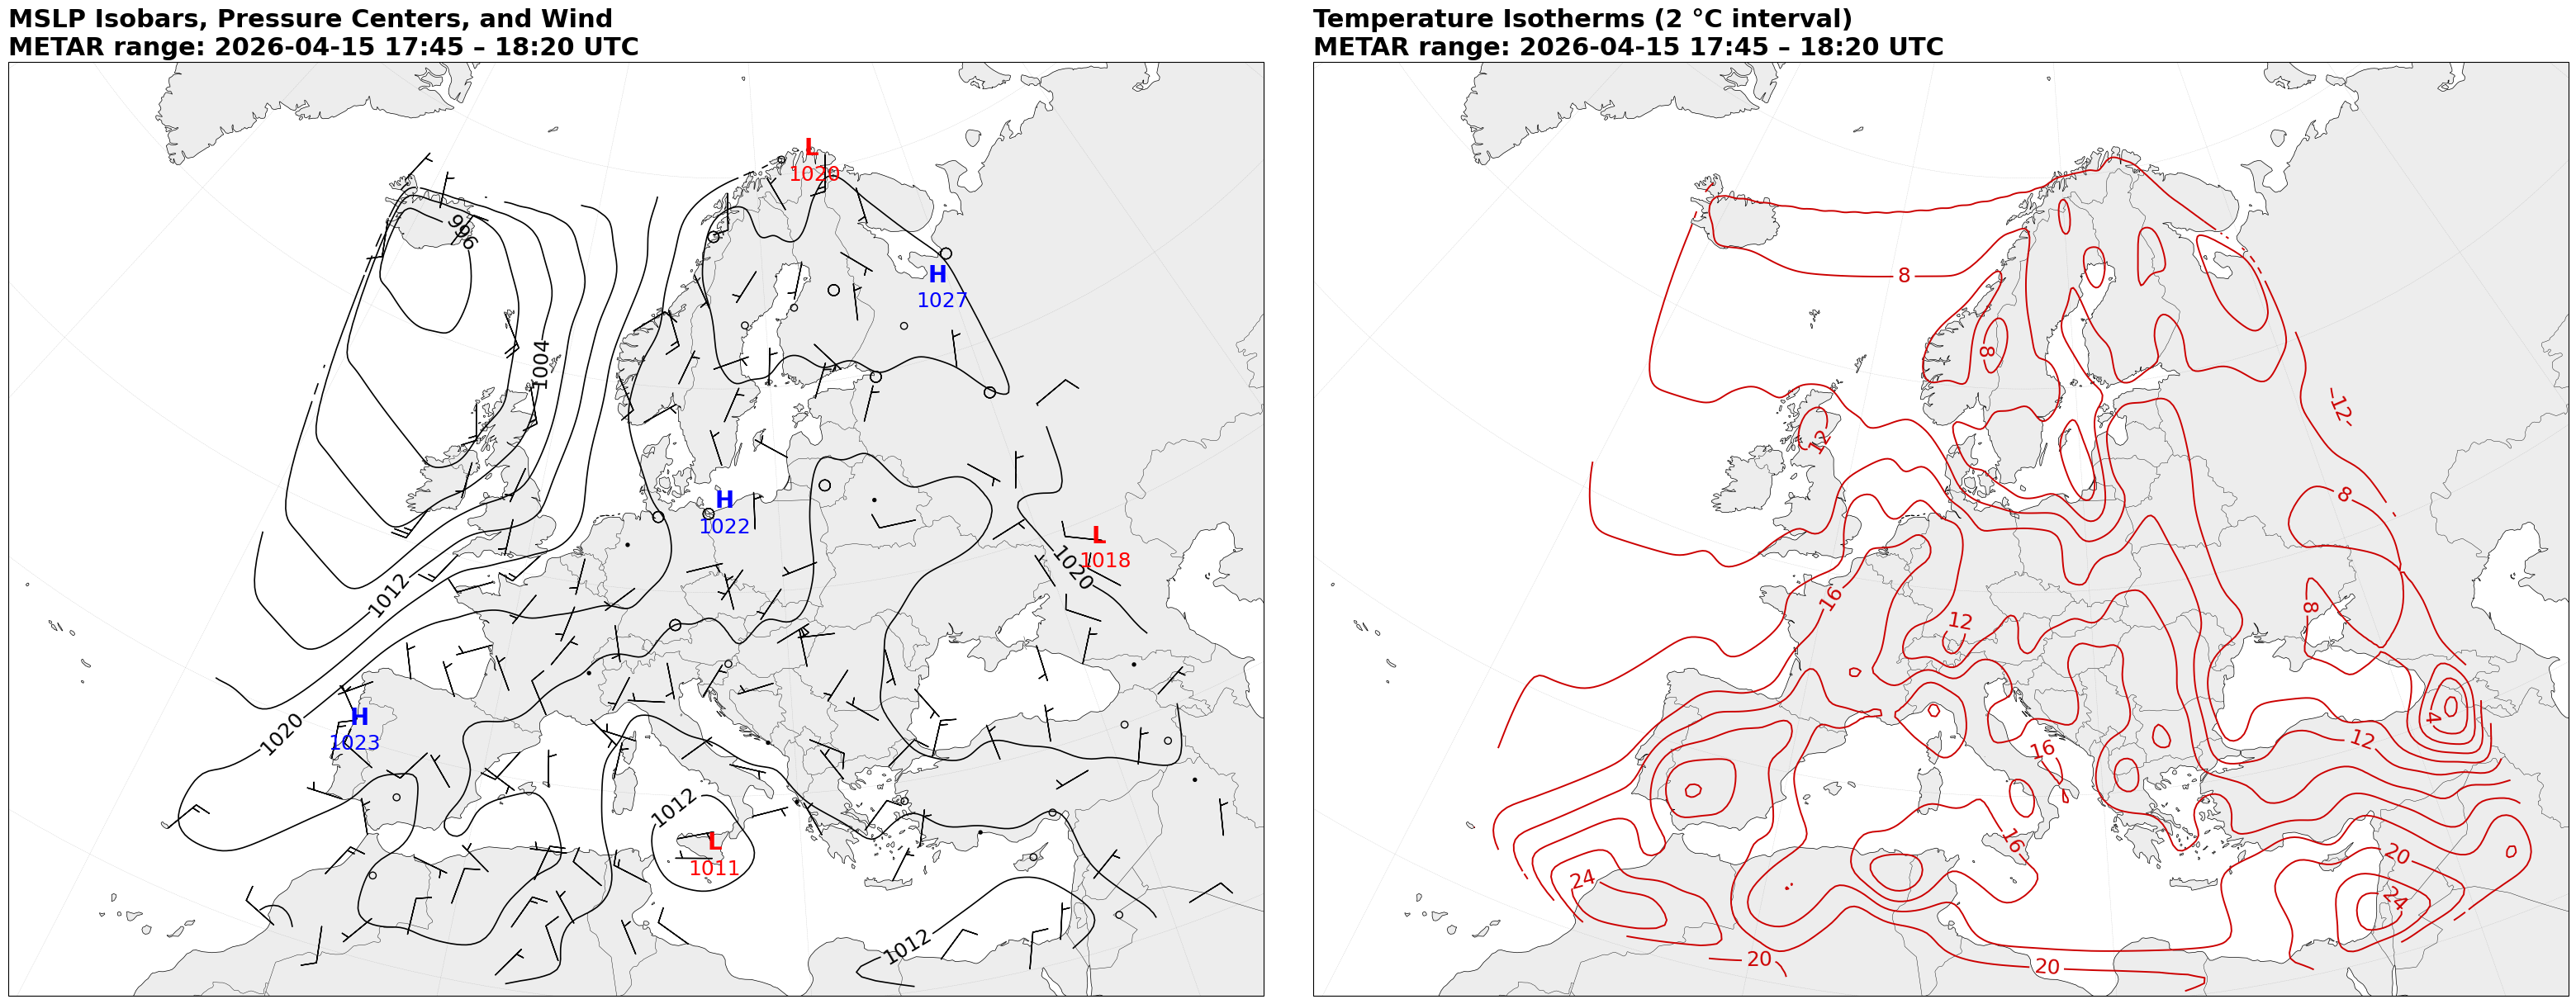

[OK]   Figure saved to E:\Professorship (2026 -\01_Projects\07_Active_Teaching\2025-2026\Μ225 Weather Analysis and Forecasting\weather-analysis-and-forecasting\outputs\europe_isobars_temperature_20260415_1835.png


In [16]:
# Isobars + H/L + wind barbs + temperature isotherms
out_path = plot_europe_isobars_temperature(
    df_plot, grid_lon, grid_lat, grids['mslp'], grids['temperature'],
    output_dir='../outputs',
    isobar_interval=ISOBAR_INTERVAL,
    isotherm_interval=ISOTHERM_INTERVAL,
)
print(f'[OK]   Figure saved to {out_path}')

---

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 4px solid #ffc107;">

## 📝 Task 3.1: Temperature Gradient

**Goal:** Identify surface frontal zones from the temperature field and assess supporting evidence from the pressure and wind fields.

Examine the map and identify surface zones that mark boundaries between contrasting air masses. 

For each zone, state what type of front the evidence supports. 

</div>

### 3.2.2 Relative Humidity

The cell below maps station relative humidity (%) alongside the isobaric and wind analysis in the left panel of the Section 3.2.1 two-panel plot.

Relative humidity indicates the degree of atmospheric saturation at the current temperature and serves as a measure for near-surface moisture content. Higher values are generally associated with the warm, moist side of a frontal zone, while lower values characterize the drier cold-air sector. 

The **moisture contrasts**, taken together with the temperature gradients, MSLP fields and wind shifts identified above, constitute supporting evidence for the presence of surface frontal zones.

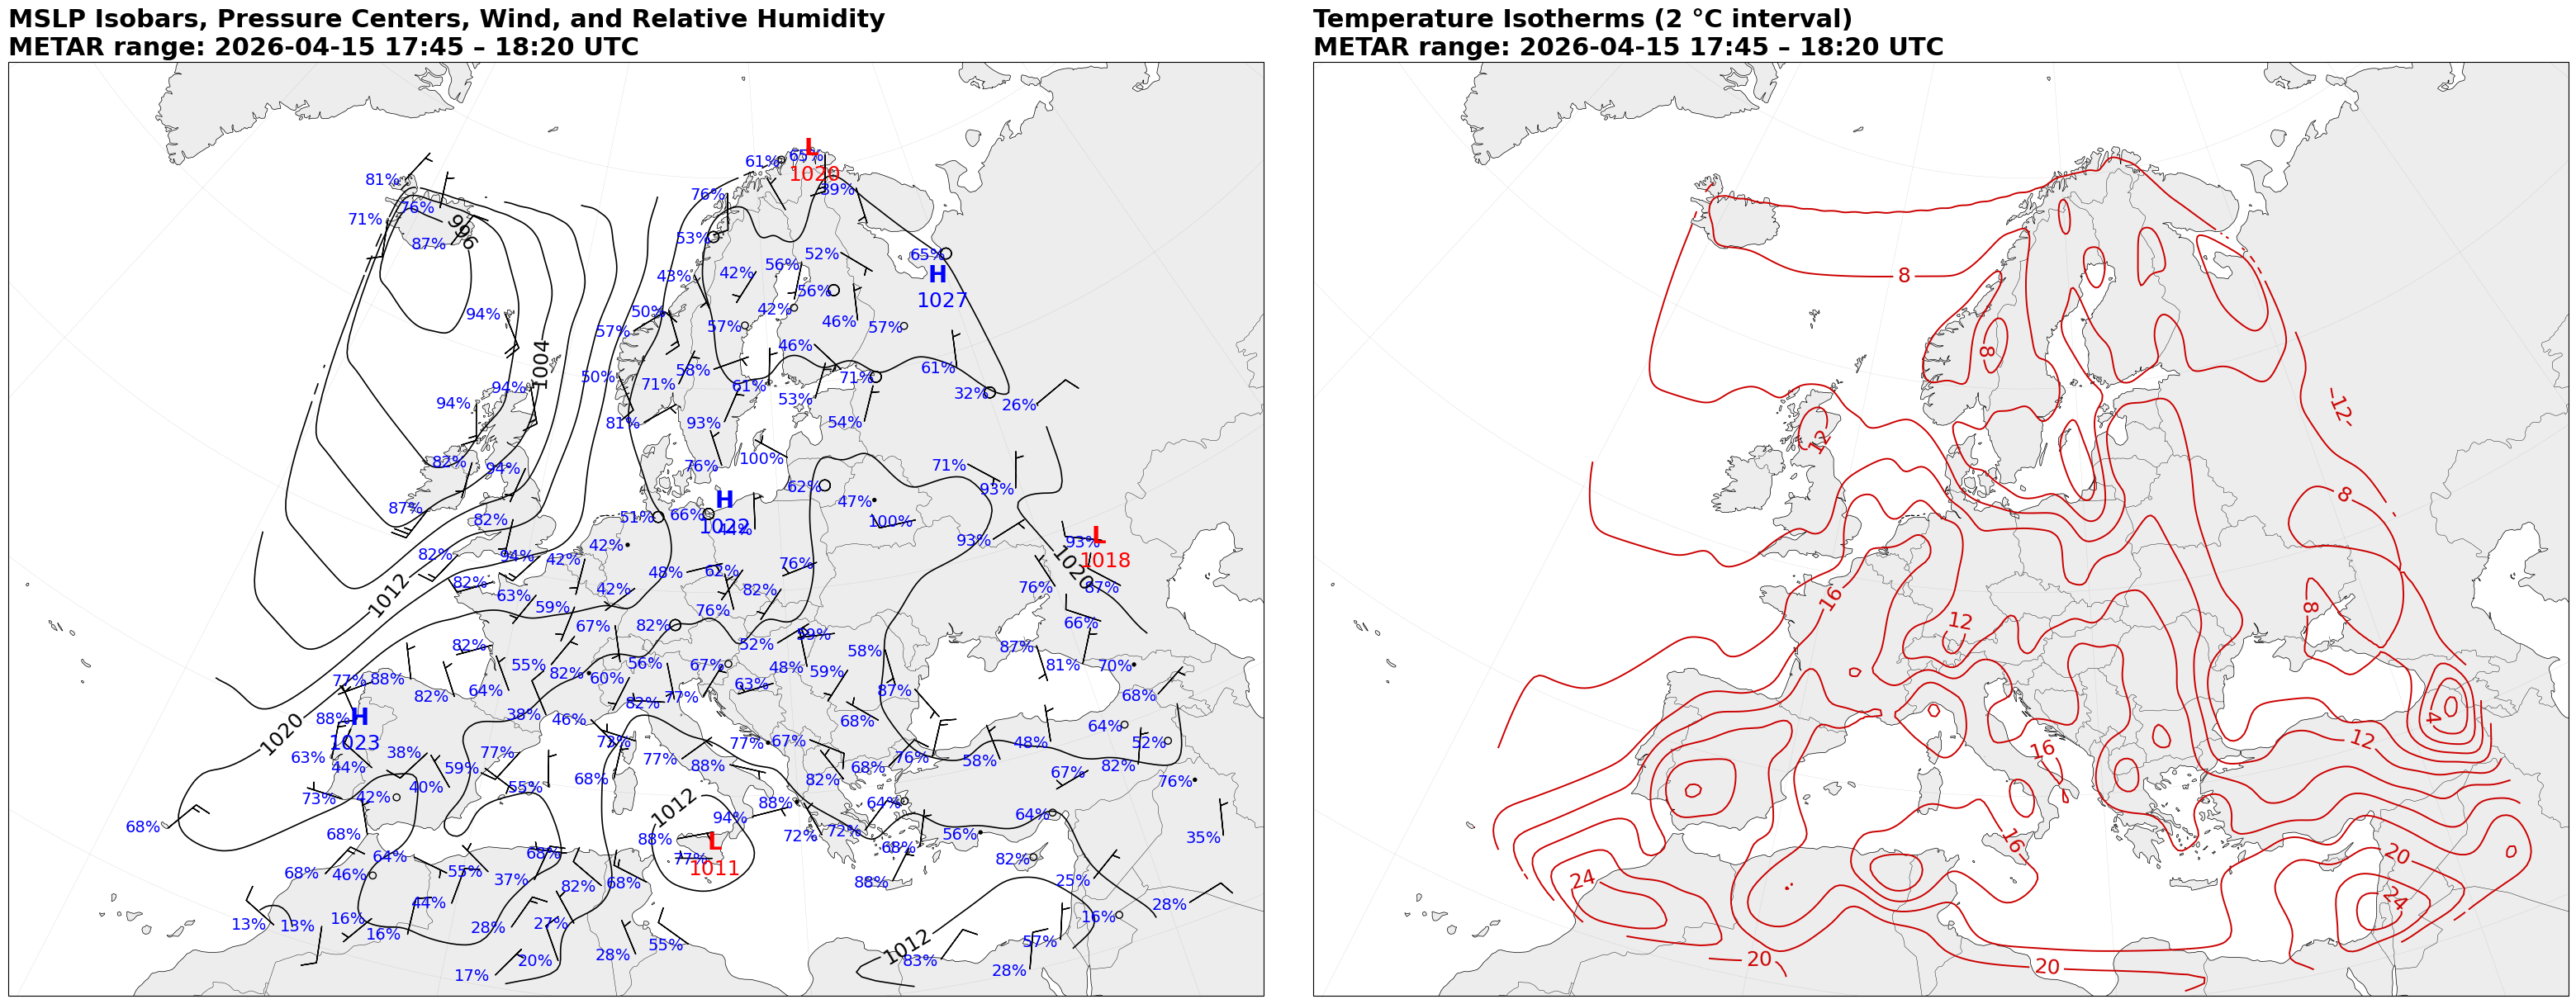

[OK]   Figure saved to E:\Professorship (2026 -\01_Projects\07_Active_Teaching\2025-2026\Μ225 Weather Analysis and Forecasting\weather-analysis-and-forecasting\outputs\europe_isobars_temperature_humidity_20260415_1835.png


In [17]:
# Isobars + H/L + wind barbs + RH labels + temperature isotherms
out_path = plot_europe_isobars_temperature_humidity(
    df_plot, grid_lon, grid_lat, grids['mslp'], grids['temperature'],
    output_dir='../outputs',
    isobar_interval=ISOBAR_INTERVAL,
    isotherm_interval=ISOTHERM_INTERVAL,
)
print(f'[OK]   Figure saved to {out_path}')

---

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 4px solid #ffc107;">

## 📝 Task 3.2: Moisture Gradient

**Goal:** Assess whether the moisture field supports the surface frontal zones identified in Task 3.1.

Examine the relative humidity distribution and revisit the zones from Task 3.1. 

Does the moisture evidence strengthen, weaken, or complicate your initial interpretation?

</div>

---

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 4px solid #ffc107;">

## 📝 Task 3.3: Validation 

**Goal:** Assess where your surface frontal analysis is consistent with and where it diverges from the UK Met Offfice (UKMO) operational analysis

*Real-time mode:* Open the UKMO surface pressure charts at 
`https://www.metoffice.gov.uk/weather/maps-and-charts/surface-pressure` 
and select the chart whose valid time is closest to your METAR  acquisition time.

*Retrospective mode:* Open the Wetterzentrale UKMO analysis archive at 
`https://www.wetterzentrale.de/en/reanalysis.php?map=1&model=bra&var=45` 
and navigate to the date and time that is closest to your METAR acquisition.

In both cases, compare your identified surface frontal zones with the operational frontal analysis.
</div>

---

# Section 4: Upper-Air Overview

## 4.1 Beyond the Surface

As mentioned in Section 3.1, METAR data can capture only the near-surface projection of three-dimensional atmospheric structures. Complete frontal analysis requires cross-referencing with upper-air charts. This section focuses on the 500 hPa isobaric level (≈5,500 m altitude, mid-troposphere), a key level for synoptic analysis directly associated with the diagnosis of the development and movement of surface pressure systems. 

## 4.2 Radiosonde Data

Upper-air soundings for the European domain are retrieved from the [University of Wyoming upper-air database](https://weather.uwyo.edu/upperair/sounding.shtml). The cell below fetches the sounding nearest in time to the target observation period for each station and extracts the 500 hPa temperature, geopotential height, wind vectors, and dew point. Stations that fail to provide sounding data (due to network errors or data unavailability) are excluded. 

In [18]:
# Build European radiosonde station list from IGRA2 (WMO-numbered sites only)
station_meta_raob = fetch_igra2_europe(LAT_MIN, LAT_MAX, LON_MIN, LON_MAX)

_start_raob = _time.time()
df_raob = fetch_europe_raob_fields(station_meta_raob)
print(f"[TIME ] {(_time.time() - _start_raob):.1f} s")
print(f'[RAOB] {df_raob["z500"].notna().sum()} stations with 500 hPa GPH  |  '
      f'{df_raob["dd500"].notna().sum()} stations with 500 hPa dew-point depression')
display(df_raob[["station_id", "latitude", "longitude",
                  "z500_dam", "t500", "td500", "dd500", "valid"]].head(10))

2026-04-15 21:35:36 | INFO | [IGRA2] 464 European radiosonde stations in bounding box
2026-04-15 21:37:27 | INFO | [RAOB] 87 / 464 stations with available sounding


[TIME ] 110.3 s
[RAOB] 83 stations with 500 hPa GPH  |  83 stations with 500 hPa dew-point depression


,station_id,latitude,longitude,z500_dam,t500,td500,dd500,valid
0,01001,70.9331,-8.6667,542.0,-30.1,-54.1,24.0,2026-04-15 12:00:00+00:00
1,01010,69.3073,16.1312,551.5,-27.4,-40.3,12.9,2026-04-15 12:00:00+00:00
2,01241,63.7045,9.6105,555.0,-23.7,-47.7,24.0,2026-04-15 12:00:00+00:00
3,01400,56.5422,3.2236,568.0,-18.5,-20.1,1.6,2026-04-15 12:00:00+00:00
4,01415,58.8725,5.6645,559.9,-20.0,-44.9,24.9,2026-04-15 12:00:00+00:00
5,02365,62.5317,17.4361,556.9,-27.0,-45.0,18.0,2026-04-15 12:00:00+00:00
6,02836,67.3666,26.6290,557.8,-27.9,-32.8,4.9,2026-04-15 12:00:00+00:00
7,02963,60.8140,23.4982,556.5,-27.2,-54.5,27.3,2026-04-15 12:00:00+00:00
8,03005,60.1392,-1.1847,556.0,-18.9,-20.3,1.4,2026-04-15 12:00:00+00:00
9,03808,50.2183,-5.3275,551.0,-25.9,-34.9,9.0,2026-04-15 12:00:00+00:00


## 4.3 500 hPa Station Plot

Four parameters are mapped across the European domain. Geopotential height is expressed in decameters (dam) and plotted as a three-digit value (e.g. 5760 m → 576 dam, coded as *576*). Air temperature is reported in degrees Celsius, while wind speed and direction are represented as barbs in m/s Dew-point depression (temperature minuts dew point) quantifies the degree of saturation. Values below 3°C indicate near-saturation and probable cloud presence aloft, whereas larger values denote dry mid-level air masses. 

Station plot layout:
- **Upper-left (red)** — temperature at 500 hPa (°C)
- **Upper-right** — geopotential height in dam
- **Lower-left (blue)** — dew-point depression (T − Td, °C)
- **Wind barb** — 500 hPa wind speed and direction (m/s)

[500 hPa] 83 stations with GPH  |  83 stations with dew-point depression


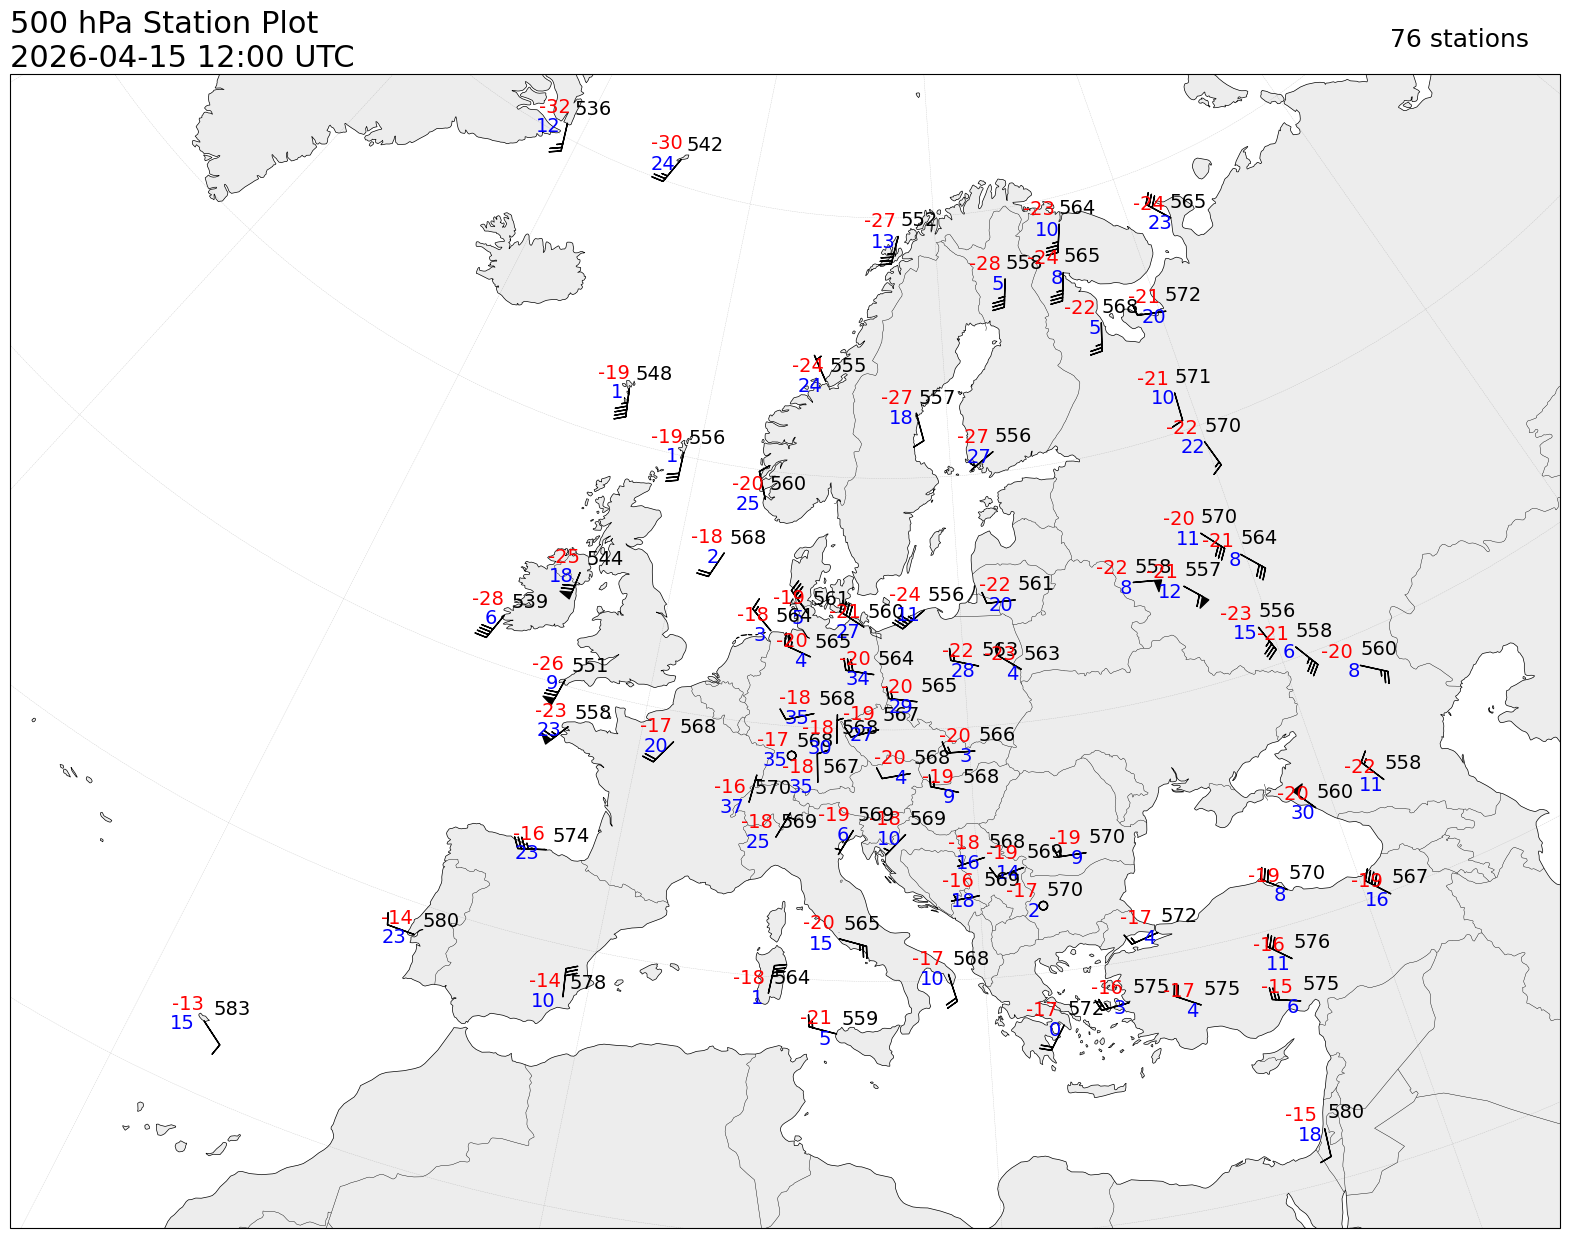

[OK]   Figure saved to E:\Professorship (2026 -\01_Projects\07_Active_Teaching\2025-2026\Μ225 Weather Analysis and Forecasting\weather-analysis-and-forecasting\outputs\europe_500hpa_stations_20260415_1837.png


In [19]:
# The z500_dam and dd500 columns are already computed by fetch_europe_raob_fields()
n_z  = df_raob["z500_dam"].notna().sum()
n_dd = df_raob["dd500"].notna().sum()
print(f"[500 hPa] {n_z} stations with GPH  |  {n_dd} stations with dew-point depression")

out_path = plot_europe_500hpa_stations(
    df_raob,
    output_dir='../outputs',
)
print(f'[OK]   Figure saved to {out_path}')
plt.show()

---

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 4px solid #ffc107;">

## 📝 Task 4.1: Upper-Air Interpretation

**Goal:** Interpret the 500 hPa station plot in relation to the surface pressure systems and frontal zone(s) identified in Sections 2 and 3.

1. Examine the 500 hPa wind barbs and geopotential height values across 
the domain. Surface cyclones tend to move in the direction of the 
upper-level flow, parallel to the geopotential height isopleths. Based 
on this, estimate the likely direction of movement of the surface lows identified in Section 2.2.3.

2. Examine the dew-point depression field in the vicinity of the frontal 
zone(s) identified in section 3.1 and identify regions of probable cloud 
development aloft.

</div>

---

<div style="background-color: #f8d7da; padding: 15px; border-radius: 8px; border-left: 4px solid #dc3545;">

## Pro Task: Retrospective Upper-Air Analysis

**Goal:** Apply the full surface and upper-air analysis workflow of Sections 2–4 to historically significant weather events over Europe.

Return to the Configuration cell (section 1.2), switch `DATA_MODE` to `'retrospective'`, and re-run all cells to apply the same analytical framework developed in Sections 2–4 for the following event: 

**Storm Ciarán**: An exceptionally deep and rapidly intensifying extratropical cyclone that affected Western Europe on 1–2 November 2023, producing record-breaking wind gusts, especially across the Channel Islands, northern France, and southern Britain. Central pressure reached approximately 953 hPa at peak intensity, making it one of the most significant windstorms to affect this region since the Great Storm of 1987. 

</div>

---

## 🏁 Summary & Key Takeaways

In this notebook, we extended the surface weather data analysis workflow 
to the continental scale and applied **objective analysis** techniques to construct a full surface synoptic analysis complemented by a first upper-air overview from radiosonde observations.


**Key Takeaways:**

* ✅ **Objective Analysis:** Station observations are interpolated onto a 
regular grid and smoothed to produce contourable fields.
* ✅ **Isobars:** Mean sea-level pressure isobars reveal the large-scale pressure field and allow systematic identification of high and low pressure centres.
* ✅ **Frontal Zones:** Surface frontal boundaries are identified from the simultaneous assessment of four near-surface-based criteria.
* ✅ **Upper-Air Overview:** Upper-air station plots at 500 hPa serve as a starting point for diagnosing the movement of surface pressure systems 
and identifying regions of probable cloud development aloft, among other features.

> **Looking Ahead:** Comprehensive upper-air analysis requires model analysis fields in place of sparse radiosonde observations. These are gridded best estimates of the atmospheric state produced by operational Numerical Weather Prediction (NWP) systems through data assimilation. The surface and upper-air synoptic charts constructed from them are introduced in the next notebook.

---

## References
1. Stull, R. (2017). *Practical Meteorology: An Algebra-based Survey of Atmospheric Science*. University of British Columbia. Available at: [https://www.eoas.ubc.ca/books/Practical_Meteorology](https://www.eoas.ubc.ca/books/Practical_Meteorology)
2. Milrad, S. (2018). *Synoptic Analysis and Forecasting: An Introductory Toolkit.* Elsevier. https://doi.org/10.1016/C2015-0-05604-0 


---

**🦉 Crafted with wisdom at One Weather Lab (OWL)**<br>
Laboratory of Meteorology and Climatology, Physics Department, University of Ioannina<br>
Christos Giannaros <<chris.giannaros@uoi.gr>>